# 🧙🏻‍♂️​ **Data Scientist Part**

## 🛠️ **Initialisation**

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

---

## 📊 **Exploration Data Analysis**
The aim is to familiarise ourselves with the raw data. This involves identifying key trends, spotting outliers and understanding the relationships between the different variables. This is the diagnostic phase, designed to establish exactly what our dataset contains.

In [38]:
# Data loading
df = pd.read_csv("../Data Engineer/clean_flights.csv")

# Data visualization
df.head()

C:\Users\natha\AppData\Local\Temp\ipykernel_2636\1263082239.py:2: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../Data Engineer/clean_flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,TIMESTAMP,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE
0,2015,1,1,4,2015-01-01 00:05:00,Alaska Airlines Inc.,98,N407AS,ANC,SEA,...,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS
1,2015,1,1,4,2015-01-01 00:10:00,American Airlines Inc.,2336,N3KUAA,LAX,PBI,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA
2,2015,1,1,4,2015-01-01 00:20:00,US Airways Inc.,840,N171US,SFO,CLT,...,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US
3,2015,1,1,4,2015-01-01 00:20:00,American Airlines Inc.,258,N3HYAA,LAX,MIA,...,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA
4,2015,1,1,4,2015-01-01 00:25:00,Alaska Airlines Inc.,135,N527AS,SEA,ANC,...,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 33 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   TIMESTAMP            str    
 5   AIRLINE              str    
 6   FLIGHT_NUMBER        int64  
 7   TAIL_NUMBER          str    
 8   ORIGIN_AIRPORT       object 
 9   DESTINATION_AIRPORT  object 
 10  SCHEDULED_DEPARTURE  int64  
 11  DEPARTURE_TIME       float64
 12  DEPARTURE_DELAY      float64
 13  TAXI_OUT             float64
 14  WHEELS_OFF           float64
 15  SCHEDULED_TIME       float64
 16  ELAPSED_TIME         float64
 17  AIR_TIME             float64
 18  DISTANCE             int64  
 19  WHEELS_ON            float64
 20  TAXI_IN              float64
 21  SCHEDULED_ARRIVAL    int64  
 22  ARRIVAL_TIME         float64
 23  ARRIVAL_DELAY        float64
 24  DIVERTED 

We have **33 columns** and **5.8 millions** lines.

### Let's do some cleaning !

In [40]:
# Number of NaN
df.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
TIMESTAMP                    0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
IATA_COD

As we can see `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY` and `WEATHER_DELAY` have a lot of Nan which is normal. So we can fill this case with 0.

In [41]:
df[['AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']] = df[['AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].fillna(value=0)
df.isna().sum()

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
TIMESTAMP                    0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY                0
LATE_AIRCRAFT_DELAY          0
WEATHER_DELAY                0
IATA_COD

We have change all the **NaN values** from `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY` and `WEATHER_DELAY` to 0.  
Now we can focus on other **NaN values**.

In [42]:
# Column withe max of NaN
max_NaN = df.isna().sum().idxmax()

print(max_NaN,"-", df[max_NaN].isna().sum())

CANCELLATION_REASON - 5729195


Here the column `CANCELLATION_REASON` has more than **5.7 millions** of NaN values. This result is normal because only few flights are cancelled.  
So the best things to do with this column is to **delete it** because it brings more noise than real information.

In [43]:
# Deleting column 'CANCELLATION_REASON'
df = df.drop(["CANCELLATION_REASON"], axis=1)

Let's check again the column with NaN values:

In [44]:
df.isna().sum()[df.isna().sum() > 0]

TAIL_NUMBER           14721
DEPARTURE_TIME        86153
DEPARTURE_DELAY       86153
TAXI_OUT              89047
WHEELS_OFF            89047
SCHEDULED_TIME            6
ELAPSED_TIME         105071
AIR_TIME             105071
WHEELS_ON             92513
TAXI_IN               92513
ARRIVAL_TIME          92513
ARRIVAL_DELAY        105071
AIR_SYSTEM_DELAY    4755640
SECURITY_DELAY      4755640
dtype: int64

As we saw earlier, let's change the NaN values of `DEPARTURE_DELAY`, `ARRIVAL_DELAY`, `AIR_SYSTEM_DELAY` and `SECURITY_DELAY` columns into 0.

In [45]:
df[['DEPARTURE_DELAY', 'ARRIVAL_DELAY','AIR_SYSTEM_DELAY', 'SECURITY_DELAY']] = df[['DEPARTURE_DELAY', 'ARRIVAL_DELAY','AIR_SYSTEM_DELAY', 'SECURITY_DELAY']].fillna(value=0)
df.isna().sum()[df.isna().sum() > 0]

TAIL_NUMBER        14721
DEPARTURE_TIME     86153
TAXI_OUT           89047
WHEELS_OFF         89047
SCHEDULED_TIME         6
ELAPSED_TIME      105071
AIR_TIME          105071
WHEELS_ON          92513
TAXI_IN            92513
ARRIVAL_TIME       92513
dtype: int64

We can suppose that a flight without value for `DEPARTURE_TIME` and `ARRIVAL_TIME` has been cancelled. Let's check that ! 

In [46]:
df[df['DEPARTURE_TIME'].isna()]['CANCELLED'].value_counts()
df[df['ARRIVAL_TIME'].isna()]['CANCELLED'].value_counts()

CANCELLED
1    89884
0     2629
Name: count, dtype: int64

Let's delete these lines because they are useless!

In [47]:
df = df.dropna(subset='DEPARTURE_TIME')
df.isna().sum()[df.isna().sum() > 0]

TAXI_OUT           2894
WHEELS_OFF         2894
SCHEDULED_TIME        6
ELAPSED_TIME      18918
AIR_TIME          18918
WHEELS_ON          6360
TAXI_IN            6360
ARRIVAL_TIME       6360
dtype: int64

Once again we have still a lot of NaN values.  
Let's remove it if necessary!

In [48]:
df[df['ELAPSED_TIME'].isna()]['DIVERTED'].value_counts()

DIVERTED
1    15187
0     3731
Name: count, dtype: int64

In [49]:
df = df.dropna(subset='ELAPSED_TIME')
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

Now we have no more NaN values which is very nice, our dataframe is clean!

### Let's convert `Timestamp` to *datetime64*

In [50]:
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'], format='%Y-%m-%d %H:%M:%S')
df.info()

<class 'pandas.DataFrame'>
Index: 5714008 entries, 0 to 5819078
Data columns (total 32 columns):
 #   Column               Dtype         
---  ------               -----         
 0   YEAR                 int64         
 1   MONTH                int64         
 2   DAY                  int64         
 3   DAY_OF_WEEK          int64         
 4   TIMESTAMP            datetime64[us]
 5   AIRLINE              str           
 6   FLIGHT_NUMBER        int64         
 7   TAIL_NUMBER          str           
 8   ORIGIN_AIRPORT       object        
 9   DESTINATION_AIRPORT  object        
 10  SCHEDULED_DEPARTURE  int64         
 11  DEPARTURE_TIME       float64       
 12  DEPARTURE_DELAY      float64       
 13  TAXI_OUT             float64       
 14  WHEELS_OFF           float64       
 15  SCHEDULED_TIME       float64       
 16  ELAPSED_TIME         float64       
 17  AIR_TIME             float64       
 18  DISTANCE             int64         
 19  WHEELS_ON            float64       
 

### Analysis of Delays  

Let's calculate the average delay per month

Text(0.5, 1.0, 'Average delay per month')

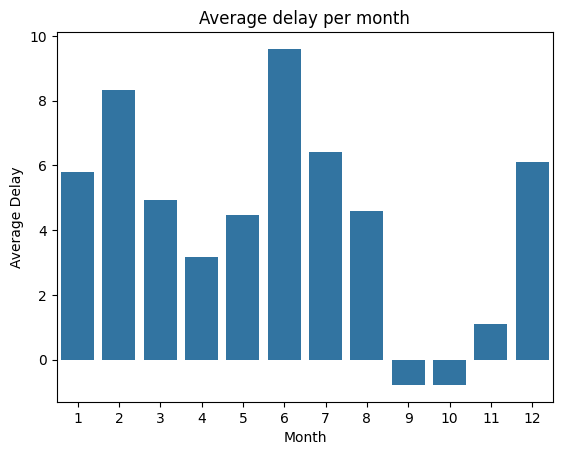

In [51]:
month_delay = df['ARRIVAL_DELAY'].groupby(df['MONTH']).mean()
# df.grouby('MONTH')['ARRIVAL_DELAY'].mean()

sns.barplot(x=month_delay.index, y=month_delay.values)
plt.xlabel("Month")
plt.ylabel("Average Delay")
title = 'Average delay per month'
plt.title(title)    

The top 3 are as follows: month 6, month 2, and month 7.  
For months 6 and 7, it’s the **summer vacation**, which makes sense. As for month 2—which is February—that’s more surprising.  
Could it be the **weather**, or perhaps a lot of maintenance work?

#### Let's see the average delay per month due to weather conditions.

Text(0.5, 1.0, 'Average weather delay per month')

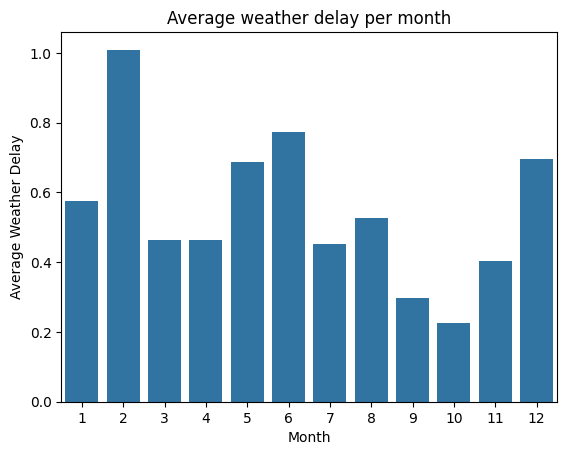

In [52]:
weather_delay = df.groupby('MONTH')['WEATHER_DELAY'].mean()

sns.barplot(x=weather_delay.index, y=weather_delay.values)
plt.xlabel("Month")
plt.ylabel("Average Weather Delay")
title = 'Average weather delay per month'
plt.title(title)   

As we see, the delay in month 2 are due to the **weather condition**, this chart proves it.

#### Now, what about the Airline?

C:\Users\natha\AppData\Local\Temp\ipykernel_2636\644238411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_delay.index, y=airline_delay.values, palette='Paired')


Text(0.5, 1.0, 'Average delay per airline')

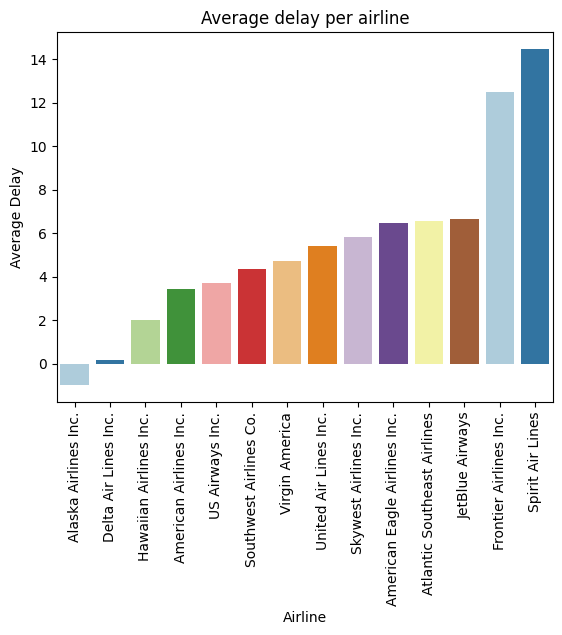

In [53]:
airline_delay = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()

sns.barplot(x=airline_delay.index, y=airline_delay.values, palette='Paired')
plt.xticks(rotation=90)
plt.xlabel("Airline")
plt.ylabel("Average Delay")
title = 'Average delay per airline'
plt.title(title) 

We can see, therefore, that the airline with the fewest delays is **Alaska Airlines Inc.** and the one with the most is **Spirit Air Lines**.

#### Let's see if some airports are more behind schedule than others.

C:\Users\natha\AppData\Local\Temp\ipykernel_2636\4136922840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_delay.index, y=airport_delay.values, palette='hls')


Text(0.5, 1.0, 'Top 10 airports with longest average departure delays')

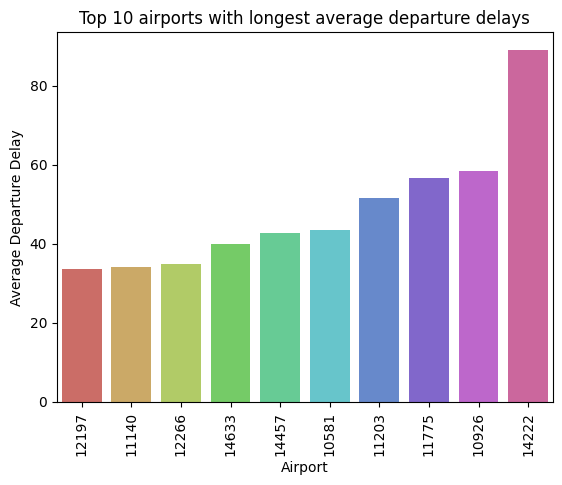

In [54]:
airport_delay = df.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().sort_values().tail(10)

sns.barplot(x=airport_delay.index, y=airport_delay.values, palette='hls')
plt.xticks(rotation=90)
plt.xlabel("Airport")
plt.ylabel("Average Departure Delay")
title = 'Top 10 airports with longest average departure delays'
plt.title(title) 

Here, our airport are unknow so it's not helpful for our analysis, let's do our analysis on airport with an **IATA_CODE** only

C:\Users\natha\AppData\Local\Temp\ipykernel_2636\2350869840.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_delay.index, y=airport_delay.values, palette='hls')


Text(0.5, 1.0, 'Top 10 airports with longest average departure delays')

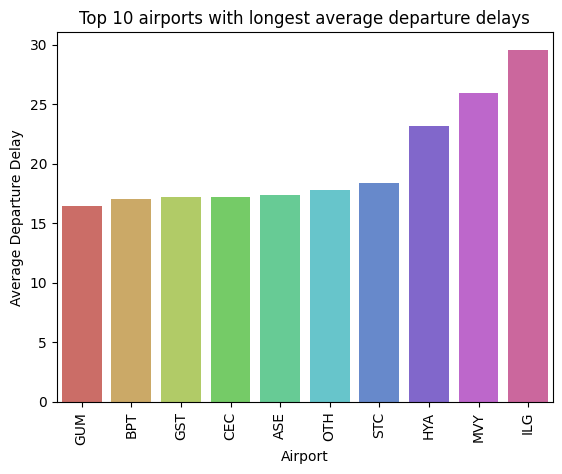

In [55]:
# Filtering our df to keep only airport with IATA Code
df_IATA_airport = df[df['ORIGIN_AIRPORT'].str.len() ==3]

airport_delay = df_IATA_airport.groupby('ORIGIN_AIRPORT')['DEPARTURE_DELAY'].mean().sort_values().tail(10)

sns.barplot(x=airport_delay.index, y=airport_delay.values, palette='hls')
plt.xticks(rotation=90)
plt.xlabel("Airport")
plt.ylabel("Average Departure Delay")
title = 'Top 10 airports with longest average departure delays'
plt.title(title) 

So the top 3 is : **GUM**, **BPT** and **GST**.

### To conclude on this section, this EDA allows us to know how the weather, the airlines and the airports influence the delays.

---

## ⚙️ **Feature Engineering**

The aim is to transform and enrich this raw data so that a machine learning algorithm can analyse it more effectively. A predictive model is purely mathematical: if it is given a specific time such as “0815”, it will struggle to generalise that this is rush hour. Feature engineering involves ‘pre-processing’ this work, for example by creating a clear category such as ‘Morning’.

Let’s create a function that takes a time as an argument and returns a string indicating whether it is morning, afternoon, evening or night.

In [56]:
# I'm going to settle our states like that : 
#       + night : 00 - 06
#       + morning : 06 - 12
#       + afternoon : 12 - 18
#       + evening : 18 - 23h59

def hour_to_timeday(hour: int) -> str:
    time = hour // 100

    if 0 <= time < 6:
        return "Night"
    elif 6 <= time < 12:
        return "Morning"
    elif 12 <= time < 18:
        return "Afternoon"
    elif 18 <= time <= 23:
        return "Evening"

Let's apply this function on our dataframe

In [57]:
df['TIME_OF_DAY'] = df['SCHEDULED_DEPARTURE'].apply(hour_to_timeday)

df["TIME_OF_DAY"].value_counts()

TIME_OF_DAY
Morning      2225963
Afternoon    2102690
Evening      1247437
Night         137918
Name: count, dtype: int64

Now let's look the average delay according to the time of day.

C:\Users\natha\AppData\Local\Temp\ipykernel_2636\2543679087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delay_by_time.index, y=delay_by_time.values, palette='Paired')


Text(0.5, 1.0, 'Average departure delay according to time of day')

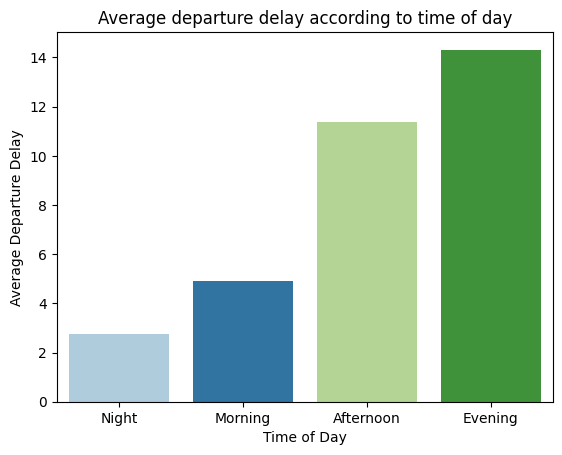

In [58]:
delay_by_time = df.groupby("TIME_OF_DAY")["DEPARTURE_DELAY"].mean().sort_values()

sns.barplot(x=delay_by_time.index, y=delay_by_time.values, palette='Paired')
plt.xlabel("Time of Day")
plt.ylabel("Average Departure Delay")
title = 'Average departure delay according to time of day'
plt.title(title)

It is noticeable that delays are at their lowest at night, which is to be expected as there are fewer flights. Delays are at their highest in the evening, which makes sense given the knock-on effect of the day’s events

### 🛠️ **Preparing for Machine Learning**

Let's prepare our data for our model. The first step is to convert the time of day in binary number.

In [59]:
df = pd.get_dummies(df, columns=['TIME_OF_DAY'])

Let's delete the columns `TAIL_NUMBER`, `TIMESTAMP`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, `IATA_CODE` and convert the column `AIRLINE` in one-hot vector.

In [60]:
# Delete some columns
df = df.drop(columns=["TAIL_NUMBER","TIMESTAMP", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "IATA_CODE"])

# Convert column AIRLINE into a one-hot vector
df = pd.get_dummies(df, columns=['AIRLINE'])

Now our data are ready to go inside our ML's model.

---

## 🤖 **Machine Learning**

Let's create (X, Y) for our model !

In [61]:
y = df['DEPARTURE_DELAY']
X = df.drop(columns=['ARRIVAL_DELAY', 'DEPARTURE_DELAY'])

Now we are going to split our dataset into train and test set.

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

### Logistic Regression

In [63]:
model = LinearRegression()

Let's train !

In [64]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Now let's test it and evaluate it !

In [65]:
# Prediction
y_pred = model.predict(X_test)

# Calculate the MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE LR = {mae:.2f}")

MAE LR = 5.89


Let's try with an other algorithm :

### XGBoost

In [66]:
# Initialise the model
XGB_model = XGBRegressor(n_estimators=100, device="cuda")

# Train it
XGB_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabet

In [67]:
# Prediction
y_pred_XGB = XGB_model.predict(X_test)

# Calculate the MAE
mae_XGB = mean_absolute_error(y_test, y_pred_XGB)
print(f"MAE XGB = {mae_XGB:.2f}")

MAE XGB = 3.46


### **Data Leakage**

As we can see our results seem a little bit too good, it's impossible to predict the delay of an airplane with a 3-minute intervals.  
So we can suspect some **Data Leakage**, let's see by what our model are influenced, in particular XGBoost:

In [68]:
ranking = pd.DataFrame(
    data=XGB_model.feature_importances_,
    index=X_train.columns,
    columns=["Score_Importance"]
).sort_values(by="Score_Importance", ascending=False)

# Top 5
print(ranking.head(5))

                     Score_Importance
LATE_AIRCRAFT_DELAY          0.333697
AIRLINE_DELAY                0.267151
WEATHER_DELAY                0.084459
AIR_SYSTEM_DELAY             0.060125
TIME_OF_DAY_Morning          0.042569


It's quite noticeable that our model are influenced in major part by columns with the answers of our questions, it's a big **Data Leakage**.  
To avoid that, we have to delete all this cheat columns from our dataset to have a real MAE. Let's do that:

In [70]:
cheat_columns = ['LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'DEPARTURE_TIME', 'TAXI_OUT', 'WHEELS_OFF', 
    'ELAPSED_TIME', 'AIR_TIME', 'WHEELS_ON', 'TAXI_IN', 'ARRIVAL_TIME', 'CANCELLED', 'DIVERTED', 'AIR_SYSTEM_DELAY','ARRIVAL_DELAY', 'DEPARTURE_DELAY']

X = df.drop(columns=cheat_columns)
X.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'FLIGHT_NUMBER',
       'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE',
       'SCHEDULED_ARRIVAL', 'TIME_OF_DAY_Afternoon', 'TIME_OF_DAY_Evening',
       'TIME_OF_DAY_Morning', 'TIME_OF_DAY_Night',
       'AIRLINE_Alaska Airlines Inc.', 'AIRLINE_American Airlines Inc.',
       'AIRLINE_American Eagle Airlines Inc.',
       'AIRLINE_Atlantic Southeast Airlines', 'AIRLINE_Delta Air Lines Inc.',
       'AIRLINE_Frontier Airlines Inc.', 'AIRLINE_Hawaiian Airlines Inc.',
       'AIRLINE_JetBlue Airways', 'AIRLINE_Skywest Airlines Inc.',
       'AIRLINE_Southwest Airlines Co.', 'AIRLINE_Spirit Air Lines',
       'AIRLINE_US Airways Inc.', 'AIRLINE_United Air Lines Inc.',
       'AIRLINE_Virgin America'],
      dtype='str')

As we can see, there are no longer any columns that our model can take to cheat.  
We can now retry to train our models and see the results.

In [72]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

# Logistic Regression
LR_model = LinearRegression()
LR_model.fit(X_train, y_train)

# Prediction
y_pred_LR = LR_model.predict(X_test)

# Calculate the MAE
mae_LR = mean_absolute_error(y_test, y_pred_LR)
print(f"MAE LR = {mae_LR:.2f}")


# XGBoost
XGB_model = XGBRegressor()
XGB_model.fit(X_train, y_train)

# Prediction
y_pred_XGB = XGB_model.predict(X_test)

# Calculate the MAE
mae_XGB = mean_absolute_error(y_test, y_pred_XGB)
print(f"MAE XGB = {mae_XGB:.2f}")

MAE LR = 18.04
MAE XGB = 17.12


Now, our results seem much more consistent with reality. We therefore assume that our models are working properly.  

### Let's test our models on real data!

In [79]:
fake_flight = X_test.iloc[[2]].copy()

# Prediction
pred_LR = LR_model.predict(fake_flight)
print(f"Delay predicted for this flight : {pred_LR[0]:.2f} minutes (LR)")

pred_XGB = XGB_model.predict(fake_flight)
print(f"Delay predicted for this flight : {pred_XGB[0]:.2f} minutes (XGB)")

Delay predicted for this flight : 10.52 minutes (LR)
Delay predicted for this flight : 6.17 minutes (XGB)


Let's visualize it!

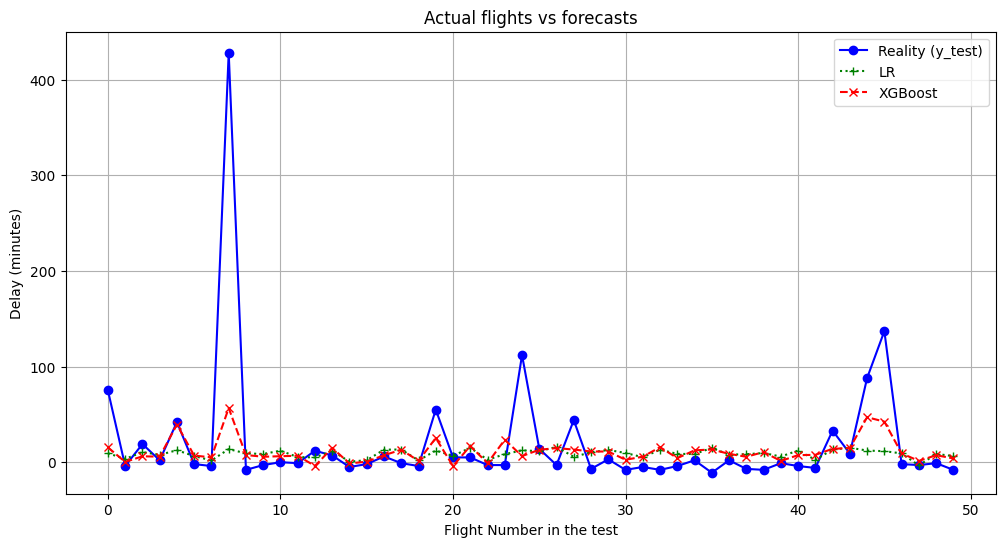

In [81]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label="Reality (y_test)", color="blue", marker='o')
plt.plot(y_pred_LR[:50], label="LR", color="green", linestyle=':', marker='+')
plt.plot(y_pred_XGB[:50], label="XGBoost", color="red", linestyle='--', marker='x')

title = "Actual flights vs forecasts"
plt.title(title)
plt.xlabel("Flight Number in the test")
plt.ylabel("Delay (minutes)")
plt.legend()
plt.grid(True)
plt.savefig(f"{title}.png", dpi=300, bbox_inches='tight')

As we can see with our predictions, the model **XGBoost** is better than the **Logistic Regression** in that case.

---

## ✈️ **Project Conclusion: Flight Delay Prediction** 

The objective of this project was to build a model capable of predicting flight arrival delays, relying exclusively on information available prior to takeoff.

#### **1. Approach and Models**
We explored and compared two prediction approaches (Regression):
* **Linear Regression:** Used as a baseline model, it showed its limitations when faced with the complexity and non-linearity of the data (smoothed errors).
* **XGBoost:** This advanced algorithm, based on an ensemble of decision trees, proved to be much more flexible in adapting to different flight scenarios.

#### **2. Key Takeaway: Data Leakage**
This project highlighted a classic trap in Machine Learning. During our initial attempts, XGBoost displayed an unrealistic Mean Absolute Error (MAE) of 3.5 minutes. The Feature Importance analysis revealed that the model was "cheating" by relying on columns populated after landing (causes of delay, exact landing time). Removing this "future data" was a crucial step to making our model genuinely predictive.

#### **3. Final Results and Limitations**
With a rigorously cleaned dataset, our honest model achieved a Mean Absolute Error of approximately 17 minutes. The final graphical analysis demonstrates an inherent reality of the field: the algorithm successfully identifies structural delays (the signal), but it cannot anticipate exceptional and sudden events (the noise) without additional information.

#### **4. Future Perspectives**
If this project were to be continued, several avenues could be explored:
* **Changing the Approach:** Transitioning from regression to classification to simply predict whether the plane will be "On Time" or "Delayed" (and thus obtain an Accuracy percentage).
* **Data Enrichment:** Integrating historical weather data or airport traffic conditions at the scheduled departure time to help the model anticipate the infamous delay spikes.